In [1]:
import os
from pathlib import Path
import random
import gc
import kagglehub
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from tqdm.auto import tqdm

import torchvision
import torchvision.transforms as T
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

In [2]:
path = "/kaggle/input/datasets/viratkothari/animal10"

In [3]:
IMG_DIR = Path(path)/'Animals-10'
print("Image directory:", IMG_DIR.exists())

Image directory: True


## EDA

In [4]:
class_dirs = sorted([fold for fold in IMG_DIR.iterdir() if fold.is_dir()])
print("Number of classes:", len(class_dirs), "\n")

Number of classes: 10 



In [5]:
# Get number of images in each class
rows = []
for class_dir in class_dirs:
    n_files = len(list(class_dir.iterdir()))
    rows.append({'class_animal': class_dir.name, 'num_images': n_files})
df_animals = pd.DataFrame(rows)
df_animals

,class_animal,num_images
0,butterfly,2112
1,cat,1668
2,chicken,3098
3,cow,1866
4,dog,4863
5,elephant,1446
6,horse,2623
7,sheep,1820
8,spider,4821
9,squirrel,1862


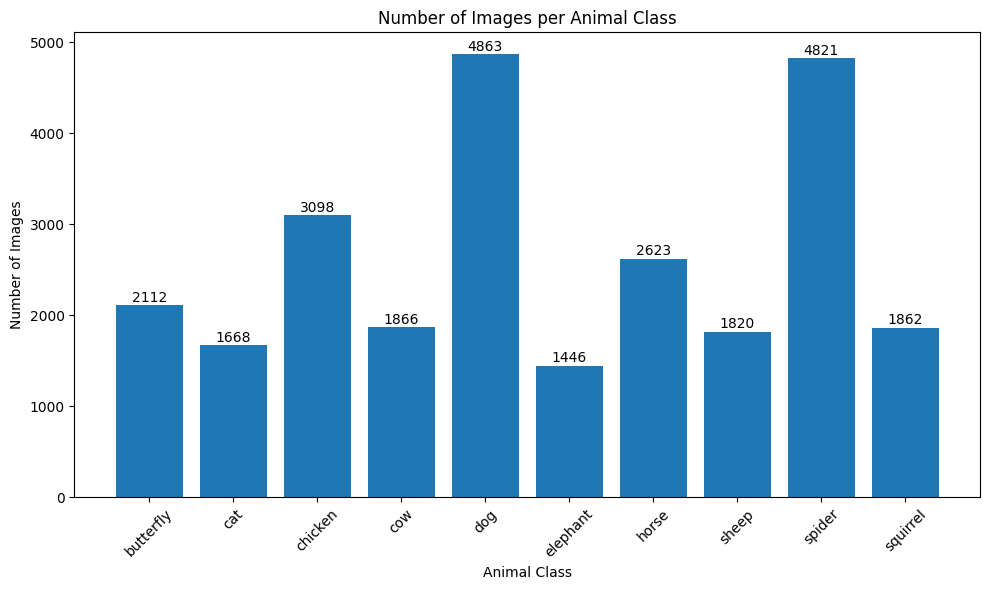

In [6]:
# Plotting the number of images per class
plt.figure(figsize=(10, 6))
bars = plt.bar(df_animals['class_animal'], df_animals['num_images'])
plt.xlabel('Animal Class')
plt.ylabel('Number of Images')
plt.title('Number of Images per Animal Class')
plt.xticks(rotation=45)
for bar in bars:
    num = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, num + 5, int(num), ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [7]:
# Count image file extensions
all_image = [picture for class_dir in class_dirs for picture in class_dir.iterdir() if picture.is_file()]
expansion_picture = Counter(picture.suffix.lower() for picture in all_image)
print("Image file extensions and their counts:", expansion_picture)

Image file extensions and their counts: Counter({'.jpeg': 24209, '.jpg': 1919, '.png': 51})


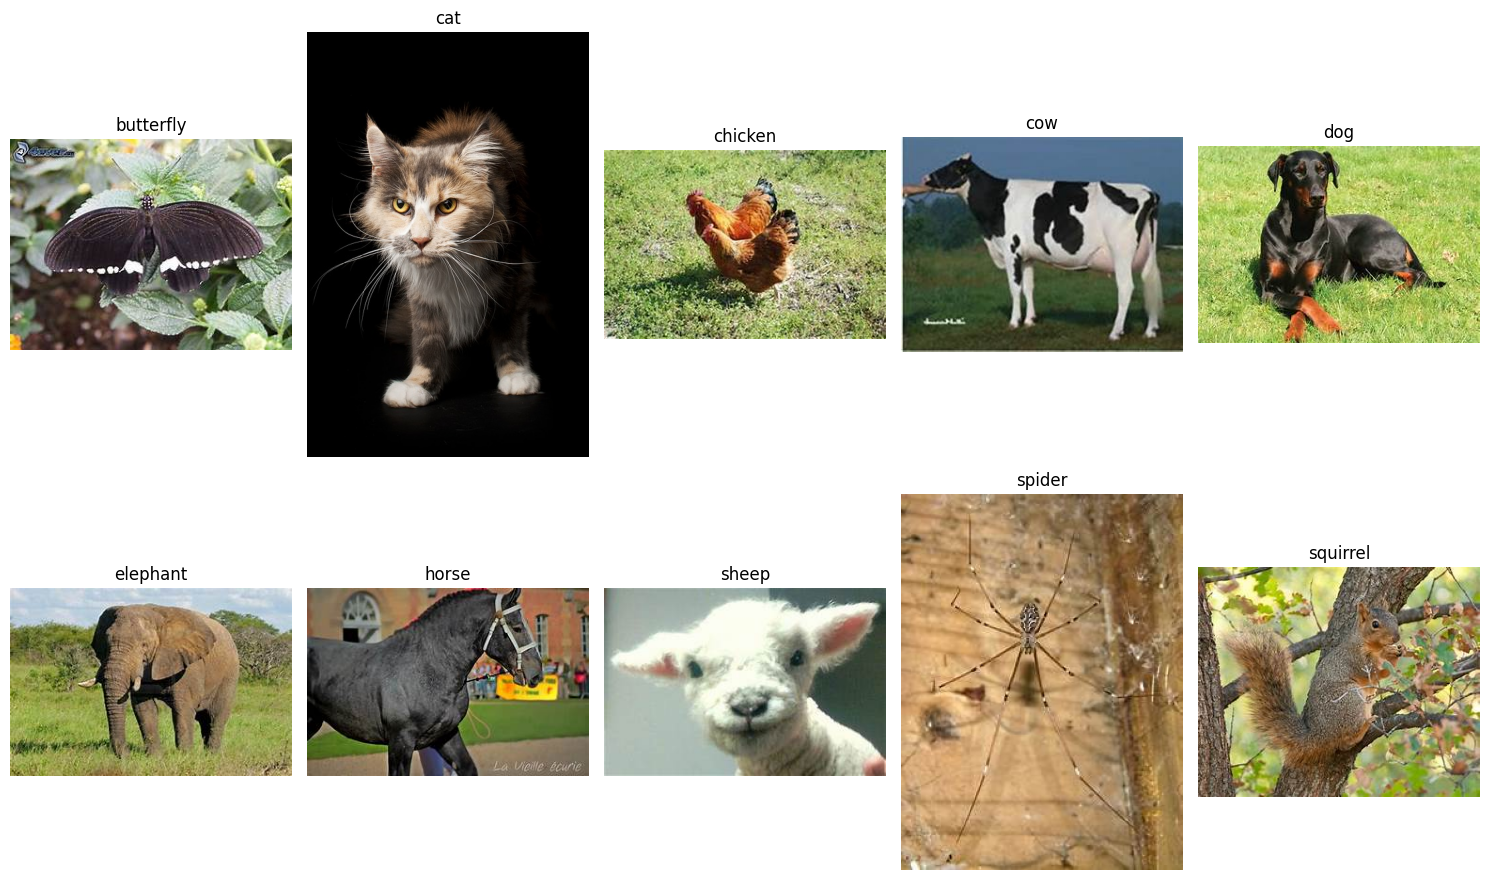

In [8]:
plt.figure(figsize=(15, 10))
for pic, class_dir in enumerate(class_dirs, start=1):
    picture = random.choice(list(class_dir.iterdir()))
    img = Image.open(picture)
    plt.subplot(2, 5, pic)
    plt.imshow(img)
    plt.title(class_dir.name)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Get image sizes
rows = []
for picture in all_image:
        width, height = img.size
        rows.append({
            "class_name": picture.parent.name,
            "width": width,
            "height": height
            })
df_sizes = pd.DataFrame(rows)
df_sizes.sample(10)

,class_name,width,height
24534,squirrel,300,244
16371,horse,300,244
24288,spider,300,244
22425,spider,300,244
19926,spider,300,244
21509,spider,300,244
1440,butterfly,300,244
6667,chicken,300,244
5083,chicken,300,244
8538,cow,300,244


In [10]:
df_sizes.describe()

,width,height
count,26179.0,26179.0
mean,300.0,244.0
std,0.0,0.0
min,300.0,244.0
25%,300.0,244.0
50%,300.0,244.0
75%,300.0,244.0
max,300.0,244.0


In [11]:
# Get image paths and class names
rows = []
for class_dir in class_dirs:
    for picture in class_dir.iterdir():
        if picture.is_file():
            rows.append({
                "pic_path": str(picture),
                "class_name": class_dir.name
            })
df_pictures = pd.DataFrame(rows)
print(df_pictures.shape)
df_pictures.sample(10)

(26179, 2)


,pic_path,class_name
10627,/kaggle/input/datasets/viratkothari/animal10/A...,dog
4926,/kaggle/input/datasets/viratkothari/animal10/A...,chicken
2059,/kaggle/input/datasets/viratkothari/animal10/A...,butterfly
4577,/kaggle/input/datasets/viratkothari/animal10/A...,chicken
25293,/kaggle/input/datasets/viratkothari/animal10/A...,squirrel
3513,/kaggle/input/datasets/viratkothari/animal10/A...,cat
712,/kaggle/input/datasets/viratkothari/animal10/A...,butterfly
14574,/kaggle/input/datasets/viratkothari/animal10/A...,elephant
5201,/kaggle/input/datasets/viratkothari/animal10/A...,chicken
23761,/kaggle/input/datasets/viratkothari/animal10/A...,spider


In [12]:
class_names = sorted(df_pictures['class_name'].unique())
idx = list(range(len(class_names)))

class_to_idx = dict(zip(class_names, idx))
idx_to_class = dict(zip(idx, class_names))
class_to_idx

{'butterfly': 0,
 'cat': 1,
 'chicken': 2,
 'cow': 3,
 'dog': 4,
 'elephant': 5,
 'horse': 6,
 'sheep': 7,
 'spider': 8,
 'squirrel': 9}

In [13]:
df_pictures['label'] = df_pictures['class_name'].map(class_to_idx)
df_pictures.sample(10)

,pic_path,class_name,label
4948,/kaggle/input/datasets/viratkothari/animal10/A...,chicken,2
728,/kaggle/input/datasets/viratkothari/animal10/A...,butterfly,0
19708,/kaggle/input/datasets/viratkothari/animal10/A...,spider,8
1916,/kaggle/input/datasets/viratkothari/animal10/A...,butterfly,0
19827,/kaggle/input/datasets/viratkothari/animal10/A...,spider,8
9241,/kaggle/input/datasets/viratkothari/animal10/A...,dog,4
15761,/kaggle/input/datasets/viratkothari/animal10/A...,horse,6
24311,/kaggle/input/datasets/viratkothari/animal10/A...,spider,8
8311,/kaggle/input/datasets/viratkothari/animal10/A...,cow,3
3383,/kaggle/input/datasets/viratkothari/animal10/A...,cat,1


In [14]:
# Split the dataset into train, validation, and test sets
train_df, temp_df = train_test_split(
    df_pictures, 
    test_size=0.2, 
    stratify=df_pictures['class_name'], 
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, 
    stratify=temp_df['class_name'], 
    random_state=42
)

print("Train set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)

Train set shape: (20943, 3)
Validation set shape: (2618, 3)
Test set shape: (2618, 3)


## Data preprocessing

In [15]:
# Define transformations for training and validation sets
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_val_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) 

In [16]:
class AnimalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pic_path = self.df.iloc[idx]['pic_path']
        label = self.df.iloc[idx]['label']
        image = Image.open(pic_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        
        return image, label 

In [17]:
train_dataset = AnimalDataset(train_df, transform=train_transforms)
val_dataset = AnimalDataset(val_df, transform=test_val_transforms)
test_dataset = AnimalDataset(test_df, transform=test_val_transforms)

In [18]:
NUM_CLASSES = 10
BATCH_SIZE = 32
NUM_WORKERS = 0 
# N_SPLITS = 5
EPOCHS = 6
LR = 1e-4     
PIN_MEMORY  = True
# PIN_MEMORY = False

In [19]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))
print("test batches :", len(test_loader))

train batches: 655
val batches  : 82
test batches : 82


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## Model initialization

In [21]:
def build_model():
    model = torchvision.models.efficientnet_b4(
        weights=EfficientNet_B4_Weights.DEFAULT
    )
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    return model

In [22]:
def build_optimizer(model):
    return torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

In [23]:
def build_criterion():
    return nn.CrossEntropyLoss()

In [24]:
model = build_model().to(device)
optimizer = build_optimizer(model)
criterion = build_criterion()

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 159MB/s]


In [25]:
# Test the model with a batch of validation data
images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Outputs shape:", outputs.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Outputs shape: torch.Size([32, 10])


## Training and validation functions

### Train

In [26]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_predictions += labels.size(0)

    epoch_loss = running_loss / total_predictions
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc

In [27]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in tqdm(dataloader, desc="Evaluating", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_predictions += labels.size(0)

    epoch_loss = running_loss / total_predictions
    epoch_acc = correct_predictions / total_predictions
    return epoch_loss, epoch_acc

In [28]:
best_acc = 0.0
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        save_path = "/kaggle/working/best_model.pth"
        torch.save(model.state_dict(), save_path)
        print(f"New best model saved with accuracy: {best_acc:.4f}")

Training:   0%|          | 0/655 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 1/6 - Train Loss: 0.5562, Train Acc: 0.8621 - Val Loss: 0.0857, Val Acc: 0.9729
New best model saved with accuracy: 0.9729


Training:   0%|          | 0/655 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 5/6 - Train Loss: 0.0335, Train Acc: 0.9890 - Val Loss: 0.0539, Val Acc: 0.9851


Training:   0%|          | 0/655 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 6/6 - Train Loss: 0.0228, Train Acc: 0.9931 - Val Loss: 0.0583, Val Acc: 0.9840


### Test

In [29]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_kappa = cohen_kappa_score(all_labels, all_preds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Cohen Kappa: {test_kappa:.4f}")

Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Test Loss: 0.0755
Test Accuracy: 0.9824
Test Cohen Kappa: 0.9800


In [30]:
with open("/kaggle/working/class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f)

idx_to_class_json = {str(k): v for k, v in idx_to_class.items()}
with open("/kaggle/working/idx_to_class.json", "w") as f:
    json.dump(idx_to_class_json, f)

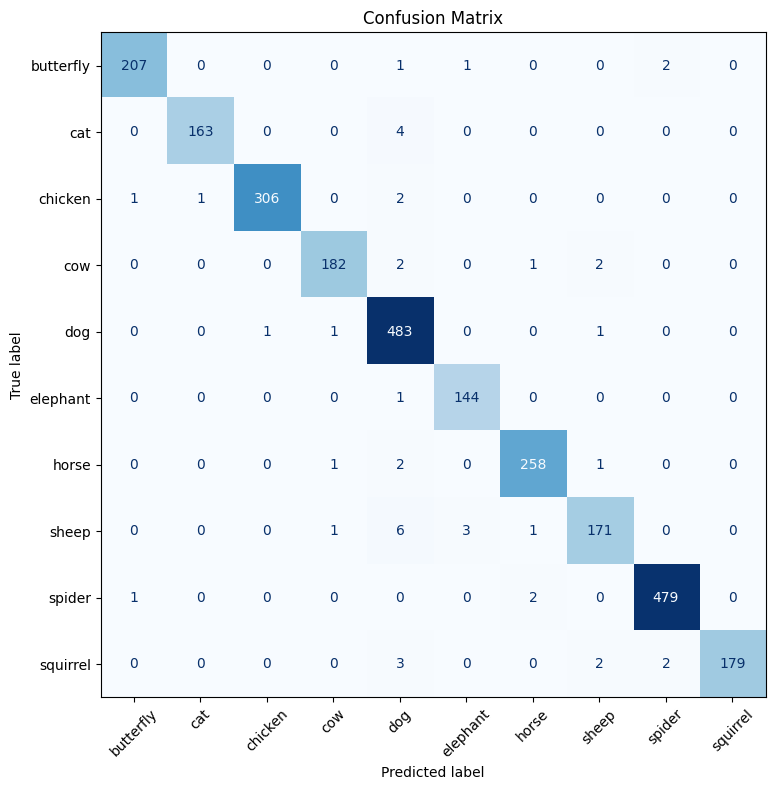

In [31]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location=device))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[idx_to_class[i] for i in range(NUM_CLASSES)]
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()